# Dekad combination

In [1]:
%load_ext jupyter_black
%load_ext autoreload
%autoreload 2

In [399]:
import calendar
import ocha_stratus as stratus
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.special import expit  # logistic function


from src.constants import *

In [4]:
blob_name = f"{PROJECT_PREFIX}/processed/iri_cerf_stats.parquet"
df_stats_iri = stratus.load_parquet_from_blob(blob_name)

In [120]:
df_stats_iri

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul,rfh_all_cumul_rank,CHIRPS Precip JAS (mm)_rank
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN,60.121881,210.054397,4.0,4.0
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN,51.311365,166.521189,1.0,1.0
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,0.0,NaN,68.003672,188.646425,12.0,12.0
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,0.0,NaN,78.242482,236.755851,18.0,17.0
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,0.0,NaN,88.517791,273.407340,30.0,29.0
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN,58.703547,190.209995,3.0,3.0
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,0.0,NaN,68.987787,199.148639,13.0,13.0
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,0.0,NaN,82.569926,239.673621,25.0,23.0
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,0.0,NaN,95.462707,333.540164,33.0,32.0
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,0.0,NaN,74.087495,278.465525,17.0,16.0


In [28]:
df_stats_iri_full = df_stats_iri[df_stats_iri["year"] < 2025]

In [5]:
blob_name = (
    f"{PROJECT_PREFIX}/processed/chirps/chirps_dek_season_cumul.parquet"
)
df_chirps_raw = stratus.load_parquet_from_blob(blob_name)

In [6]:
df_chirps_raw

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall
0,1981-07-01,6.217109,26.439596,1981,6.217109,26.439596,1,19
1,1981-07-11,4.196940,14.369387,1981,10.414049,40.808983,2,20
2,1981-07-21,13.793546,50.955724,1981,24.207595,91.764707,3,21
3,1981-08-01,8.613187,38.008222,1981,32.820782,129.772929,1,22
4,1981-08-11,6.975212,17.575585,1981,39.795994,147.348513,2,23
...,...,...,...,...,...,...,...,...
400,2025-08-11,14.622507,37.223278,2025,38.626457,118.941812,2,23
401,2025-08-21,6.727946,26.086023,2025,45.354403,145.027834,3,24
402,2025-09-01,11.359299,39.957623,2025,56.713702,184.985458,1,25
403,2025-09-11,6.046738,4.695130,2025,62.760440,189.680587,2,26


In [94]:
df_dek = df_chirps_raw[
    (df_chirps_raw["year"] < 2025) & (df_chirps_raw["year"] >= 1991)
].copy()

In [95]:
df_chirps_final = df_chirps_raw[df_chirps_raw["dekad_overall"] == 27]

In [96]:
df_stats_iri_full = df_stats_iri_full.merge(
    df_chirps_final[["year", "rfh_all_cumul", "rfh_aoi_cumul"]]
)

<Axes: xlabel='CHIRPS Precip JAS (mm)'>

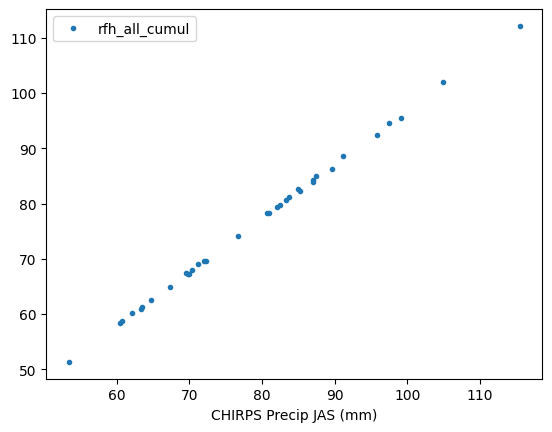

In [97]:
df_stats_iri_full.plot(
    x="CHIRPS Precip JAS (mm)", y="rfh_all_cumul", linewidth=0, marker="."
)

In [98]:
df_stats_iri_full.corr(numeric_only=True, method="spearman")["rfh_all_cumul"][
    "CHIRPS Precip JAS (mm)"
]

np.float64(0.9983956022720397)

In [99]:
for col in ["rfh_all_cumul", "CHIRPS Precip JAS (mm)"]:
    df_stats_iri_full[f"{col}_rank"] = df_stats_iri_full[col].rank(
        ascending=True
    )

In [100]:
df_stats_iri_full.sort_values("rfh_all_cumul_rank")

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),emdat_float,Amount in US$,rfh_all_cumul,rfh_aoi_cumul,rfh_all_cumul_rank,CHIRPS Precip JAS (mm)_rank,obsv_target
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,0.0,NaN,51.311365,166.521189,1.0,1.0,True
11,2002,32.4,34.3,40.5,34.2,38.1,35.1,7.0,None,60.4,0.0,NaN,58.278898,197.796330,2.0,2.0,True
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,0.0,NaN,58.703547,190.209995,3.0,3.0,True
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,0.0,NaN,60.121881,210.054397,4.0,4.0,True
28,2019,22.7,28.4,32.4,33.0,30.2,32.8,8.0,None,63.3,0.0,0.0,60.968869,174.521821,5.0,5.0,True
20,2011,36.5,35.9,26.9,41.0,35.0,27.5,2.0,Bad,63.5,1.0,4005971.0,61.178384,194.645161,6.0,6.0,False
26,2017,30.7,39.1,35.4,35.9,31.8,24.8,6.0,None,64.7,0.0,3975873.0,62.546641,206.154328,7.0,7.0,False
23,2014,30.8,35.3,42.2,40.8,39.2,29.7,4.0,None,67.3,0.0,2532163.0,64.870469,256.714735,8.0,8.0,False
13,2004,32.8,29.3,34.5,33.9,35.4,34.2,16.0,None,69.8,0.0,NaN,67.242343,261.750161,9.0,10.0,False
30,2021,20.9,14.9,18.3,19.6,18.7,21.2,10.0,None,70.0,0.0,0.0,67.317151,239.623656,10.0,11.0,False


<Axes: xlabel='year'>

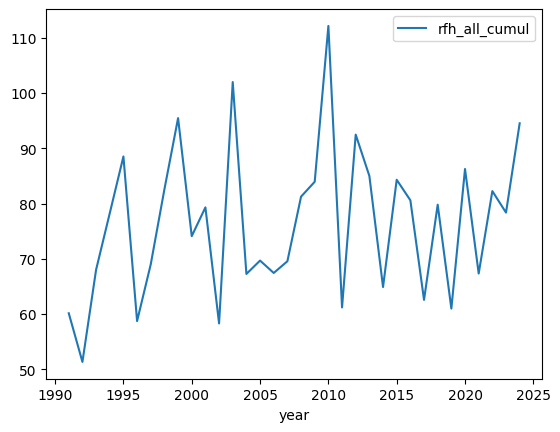

In [101]:
df_stats_iri_full.plot(x="year", y="rfh_all_cumul")

In [122]:
n_total_years = df_dek["year"].nunique()
rp_overall_target = 7
n_years_overall_target = int((n_total_years + 1) / rp_overall_target)

In [123]:
n_years_overall_target

5

In [124]:
col = "rfh_all_cumul"

df_stats_iri["obsv_target"] = (
    df_stats_iri[col]
    <= df_stats_iri[col].nsmallest(n_years_overall_target).max()
)

In [125]:
df_stats_iri_full

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),...,obsv_target,dek_19_trig,dek_20_trig,dek_21_trig,dek_22_trig,dek_23_trig,dek_24_trig,dek_25_trig,dek_26_trig,dek_27_trig
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,...,True,False,False,False,False,False,False,False,False,True
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,...,True,False,False,False,False,True,True,True,True,True
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,...,False,False,False,False,False,False,False,False,False,False
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,...,False,False,False,False,False,False,False,False,False,False
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,...,False,False,False,False,False,False,False,False,False,False
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,...,True,False,False,False,False,False,False,True,False,True
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,...,False,False,False,False,False,False,False,False,False,False
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,...,False,False,False,False,False,False,False,False,False,False
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,...,False,False,False,False,False,False,False,False,False,False
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,...,False,False,False,False,False,False,False,False,False,False


In [126]:
df_dek[df_dek["obsv_target"]]

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,obsv_target
0,1991-07-01,5.617332,18.406073,1991,5.617332,18.406073,1,19,True
1,1991-07-11,3.912060,15.553448,1991,9.529392,33.959520,2,20,True
2,1991-07-21,6.490611,18.647058,1991,16.020003,52.606578,3,21,True
3,1991-08-01,4.910419,17.289690,1991,20.930421,69.896268,1,22,True
4,1991-08-11,10.776464,49.020874,1991,31.706886,118.917142,2,23,True
5,1991-08-21,11.350063,28.991777,1991,43.056948,147.908919,3,24,True
6,1991-09-01,7.084212,26.142947,1991,50.141160,174.051866,1,25,True
7,1991-09-11,5.392294,22.769767,1991,55.533454,196.821633,2,26,True
8,1991-09-21,4.588427,13.232764,1991,60.121881,210.054397,3,27,True
9,1992-07-01,3.442676,11.414927,1992,3.442676,11.414927,1,19,True


In [245]:
dicts = []
for dekad, group in df_dek.groupby("dekad_overall"):
    for _trig_years in range(n_years_overall_target, -1, -1):
        _thresh = (
            group[col].nsmallest(_trig_years).max()
            + group[col].nsmallest(_trig_years + 1).max()
        ) / 2
        group["_trigger"] = group[col] <= _thresh
        fp = group["_trigger"] & ~group["obsv_target"]
        if not fp.any():
            df_stats_iri[f"d{dekad}_trig"] = df_stats_iri["year"].isin(
                group[group["_trigger"]]["year"].unique()
            )
            dicts.append(
                {"dekad": dekad, "thresh": _thresh, "n_years": _trig_years}
            )
            break

df_threshs = pd.DataFrame(dicts)

In [246]:
df_threshs

,dekad,thresh,n_years
0,19,NaN,0
1,20,6.029670,2
2,21,9.886243,1
3,22,17.781360,2
4,23,28.776061,3
5,24,41.703811,3
6,25,47.855195,3
7,26,53.117207,2
8,27,61.073626,5


In [247]:
def highlight_true(val):
    if isinstance(val, bool) and val is True:
        return "background-color: crimson"
    return ""

In [248]:
cols = [f"d{x}_trig" for x in range(19, 28)]

In [249]:
df_stats_iri.set_index("year")[cols].style.map(highlight_true)

,d19_trig,d20_trig,d21_trig,d22_trig,d23_trig,d24_trig,d25_trig,d26_trig,d27_trig
year,,,,,,,,,
1991,False,False,False,False,False,False,False,False,True
1992,False,False,False,False,True,True,True,True,True
1993,False,False,False,False,False,False,False,False,False
1994,False,False,False,False,False,False,False,False,False
1995,False,False,False,False,False,False,False,False,False
1996,False,False,False,False,False,False,True,False,True
1997,False,False,False,False,False,False,False,False,False
1998,False,False,False,False,False,False,False,False,False
1999,False,False,False,False,False,False,False,False,False


<Axes: >

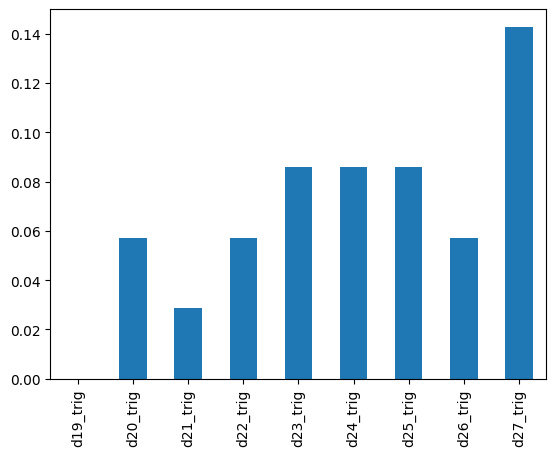

In [264]:
df_stats_iri.set_index("year")[cols].mean().plot.bar()

In [255]:
df_dek = df_dek.drop(columns=["thresh"]).merge(
    df_threshs.rename(columns={"dekad": "dekad_overall"}), how="left"
)

In [256]:
df_dek["obsv_trig"] = df_dek["rfh_all_cumul"] <= df_dek["thresh"]

In [257]:
df_dek[df_dek["dekad_overall"] == 27].sort_values("rfh_all_cumul")

,date,rfh_all,rfh_aoi,year,rfh_all_cumul,rfh_aoi_cumul,dekad,dekad_overall,obsv_target,n_years,obsv_trig,thresh
17,1992-09-21,2.871721,10.199241,1992,51.311365,166.521189,3,27,True,5,True,61.073626
107,2002-09-21,6.587397,13.595193,2002,58.278898,197.796330,3,27,True,5,True,61.073626
53,1996-09-21,4.115955,18.273877,1996,58.703547,190.209995,3,27,True,5,True,61.073626
8,1991-09-21,4.588427,13.232764,1991,60.121881,210.054397,3,27,True,5,True,61.073626
260,2019-09-21,5.632800,16.846300,2019,60.968869,174.521821,3,27,True,5,True,61.073626
188,2011-09-21,5.701405,35.481973,2011,61.178384,194.645161,3,27,False,5,False,61.073626
242,2017-09-21,8.003728,23.851360,2017,62.546641,206.154328,3,27,False,5,False,61.073626
215,2014-09-21,5.446877,28.088552,2014,64.870469,256.714735,3,27,False,5,False,61.073626
125,2004-09-21,3.601224,11.997470,2004,67.242343,261.750161,3,27,False,5,False,61.073626
278,2021-09-21,3.371929,7.050601,2021,67.317151,239.623656,3,27,False,5,False,61.073626


[None, None]

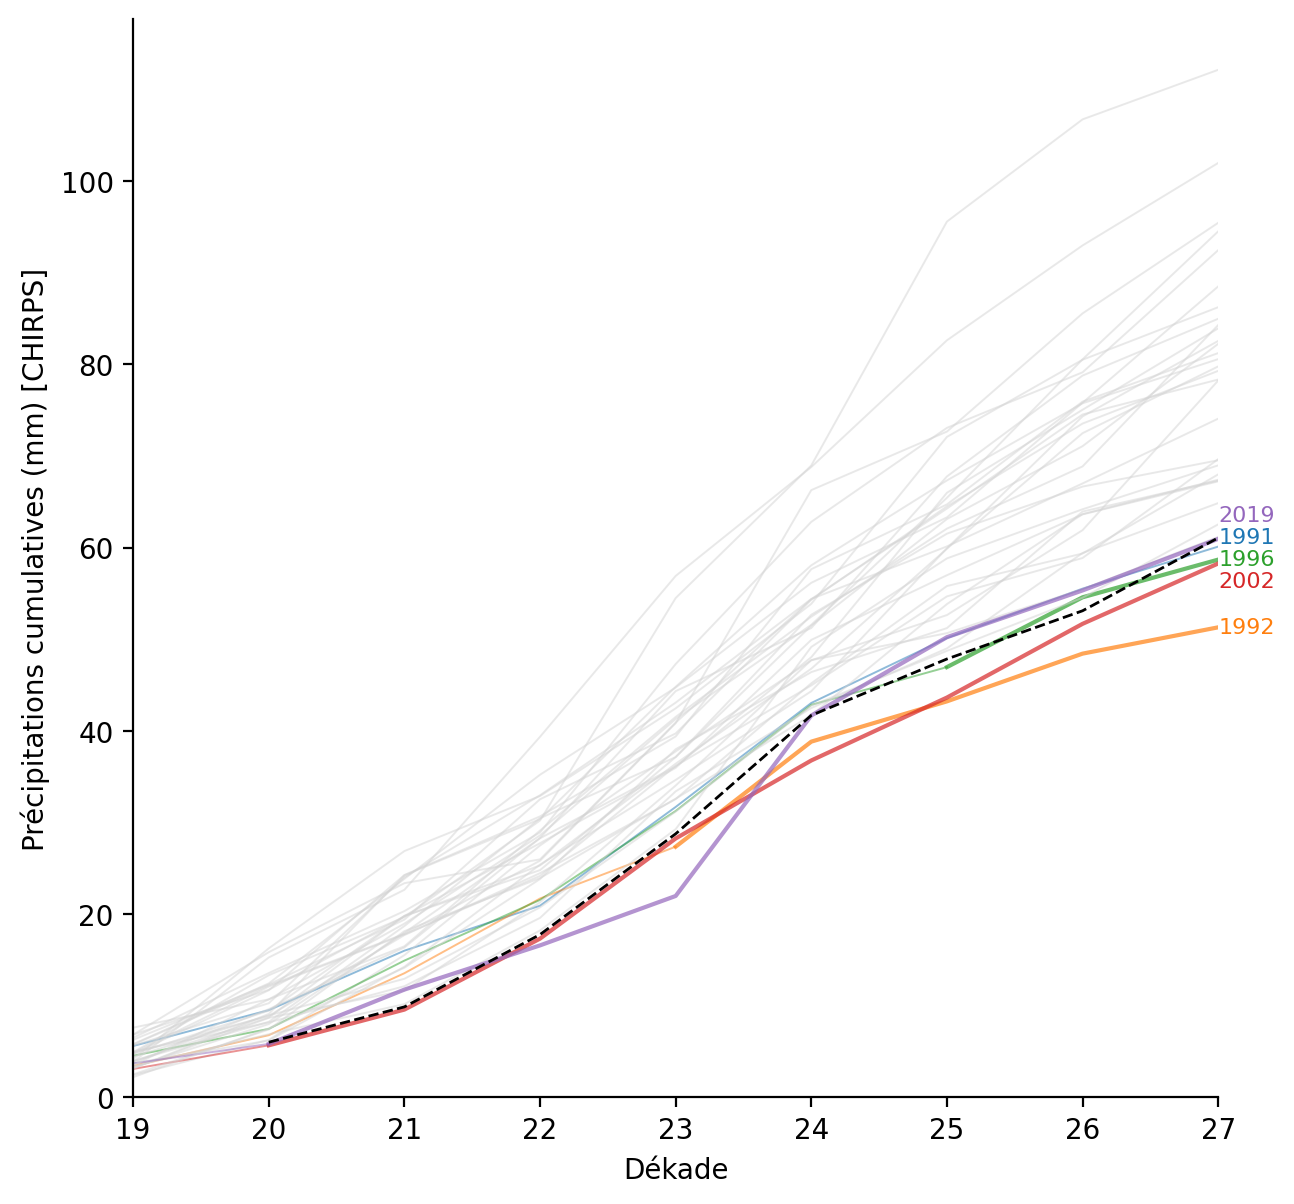

In [265]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 7), dpi=200)

col = "rfh_all_cumul"

cmap = plt.cm.tab10
color_idx = 0

year_colors = {}  # store colors for triggered years

for year, group in df_dek.groupby("year"):

    first_dek_trig = group[group["obsv_trig"]]["dekad_overall"].min()
    any_trig = group["obsv_trig"].any()

    if any_trig:
        color = cmap(color_idx % cmap.N)
        year_colors[year] = color
        color_idx += 1
    else:
        color = "lightgrey"

    if any_trig:
        group_trig = group[group["dekad_overall"] >= first_dek_trig]
        group_notrig = group[group["dekad_overall"] <= first_dek_trig]
    else:
        group_trig = group.iloc[0:0]
        group_notrig = group

    if len(group_trig):
        group_trig.plot(
            x="dekad_overall",
            y=col,
            ax=ax,
            color=color,
            alpha=0.7,
            linewidth=1.5,
        )

    group_notrig.plot(
        x="dekad_overall",
        y=col,
        ax=ax,
        color=color,
        alpha=0.5,
        linewidth=0.7,
    )

df_threshs.plot(
    x="dekad",
    y="thresh",
    ax=ax,
    color="k",
    linewidth=1,
    linestyle="--",
)

# ---- annotate years on right edge ----

x_text = 27  # slightly beyond axis limit

y_adj = {
    2019: 2.5,
    1991: 1,
    1996: 0,
    2002: -2,
}

for year, color in year_colors.items():
    group = df_dek[df_dek["year"] == year]

    # get last dekad value within plotting window
    last_row = group[group["dekad_overall"] == 27]

    if not last_row.empty:
        y_val = last_row[col].values[0]
        ax.text(
            x_text,
            y_val + y_adj.get(year, 0),
            str(year),
            color=color,
            fontsize=8,
            va="center",
        )

# formatting
ax.set_xlabel("Dékade")
ax.set_ylabel("Précipitations cumulatives (mm) [CHIRPS]")
ax.set_xlim((19, 27))  # extend slightly for labels
ax.set_ylim(bottom=0)

ax.legend().set_visible(False)

[ax.spines[x].set_visible(False) for x in ["top", "right"]]

In [381]:
df_model = df_stats_iri[df_stats_iri["year"] >= 1991].copy()
df_model["obsv_target"] = df_model["obsv_target"].astype(int)

# Center year for stability
df_model["year_c"] = df_model["year"] - df_model["year"].mean()

# Design matrix
X = sm.add_constant(df_model["year_c"])
y = df_model["obsv_target"]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.353138
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            obsv_target   No. Observations:                   35
Model:                          Logit   Df Residuals:                       33
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.1389
Time:                        22:18:36   Log-Likelihood:                -12.360
converged:                       True   LL-Null:                       -14.354
Covariance Type:            nonrobust   LLR p-value:                   0.04581
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.1948      0.668     -3.283      0.001      -3.505      -0.885
year_c        -0.1096      0.

In [382]:
odds_ratio = np.exp(result.params["year_c"])
print("Odds ratio per year:", odds_ratio)

Odds ratio per year: 0.896179522893064


In [383]:
next_year = df_model["year"].max() + 1
next_year_c = next_year - df_model["year"].mean()

X_next = sm.add_constant(np.array([[next_year_c]]), has_constant="add")

p_next = result.predict(X_next)[0]

print(f"Predicted probability for {next_year}: {p_next:.3f}")

Predicted probability for 2026: 0.015


Text(0, 0.5, 'Estimated return period')

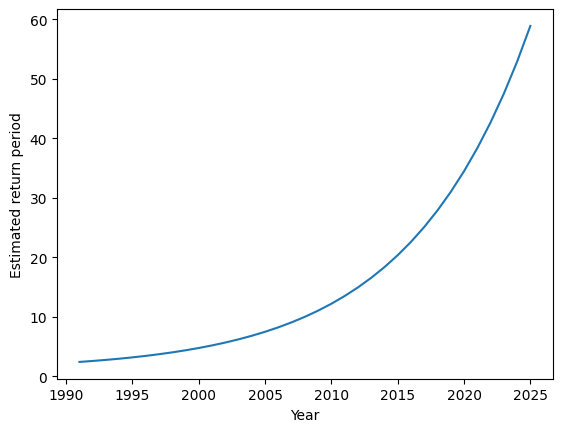

In [384]:
df_model["p_hat"] = result.predict(X)
df_model["rp_hat"] = 1 / df_model["p_hat"]

fig, ax = plt.subplots()

# ax.scatter(df_model["year"], df_model["obsv_target"], alpha=0.6)
ax.plot(df_model["year"], df_model["rp_hat"])

# ax.set_ylim(-0.05, 1.05)
ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")

In [385]:
df_model.groupby(df_model["year"] > df_model["year"].median())[
    "obsv_target"
].mean()

year
False    0.222222
True     0.058824
Name: obsv_target, dtype: float64

In [386]:
df_model.columns

Index(['year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
       'Humanitarian Bad Years (rank)', 'EM-DAT Bad Years',
       'CHIRPS Precip JAS (mm)', 'emdat_float', 'Amount in US$',
       'rfh_all_cumul', 'rfh_aoi_cumul', 'rfh_all_cumul_rank',
       'CHIRPS Precip JAS (mm)_rank', 'obsv_target', 'dek_19_trig',
       'dek_20_trig', 'dek_21_trig', 'dek_22_trig', 'dek_23_trig',
       'dek_24_trig', 'dek_25_trig', 'dek_26_trig', 'dek_27_trig', 'd19_trig',
       'd20_trig', 'd21_trig', 'd22_trig', 'd23_trig', 'd24_trig', 'd25_trig',
       'd26_trig', 'd27_trig', 'year_c', 'p_hat', 'rp_hat'],
      dtype='object')

In [387]:
rp_model = 5

nyears_trig_model = int((len(df_model) + 1) / rp_model)

In [388]:
nyears_trig_model

7

In [389]:
for col in ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "rfh_all_cumul_rank"]:
    print(col)
    # Design matrix
    X = sm.add_constant(df_model["year_c"])
    y = df_model[col]

    # Fit logistic regression
    model = sm.OLS(y, X)
    result = model.fit()

    print(result.summary())

Jan
                            OLS Regression Results                            
Dep. Variable:                    Jan   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     32.03
Date:                Tue, 24 Feb 2026   Prob (F-statistic):           2.63e-06
Time:                        22:18:37   Log-Likelihood:                -91.019
No. Observations:                  35   AIC:                             186.0
Df Residuals:                      33   BIC:                             189.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         30.3571      0.567     53.500     

In [421]:
col = "Jun"

thresh = df_model[col].nlargest(nyears_trig_model).min()
df_model[f"{col}_trig"] = (df_model[col] >= thresh).astype(int)

In [422]:
thresh

np.float64(35.1)

                            OLS Regression Results                            
Dep. Variable:                    Jun   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.488
Method:                 Least Squares   F-statistic:                     33.44
Date:                Wed, 25 Feb 2026   Prob (F-statistic):           1.83e-06
Time:                        10:36:03   Log-Likelihood:                -103.06
No. Observations:                  35   AIC:                             210.1
Df Residuals:                      33   BIC:                             213.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         29.8000      0.800     37.229      0.0

Text(0, 0.5, 'Jun')

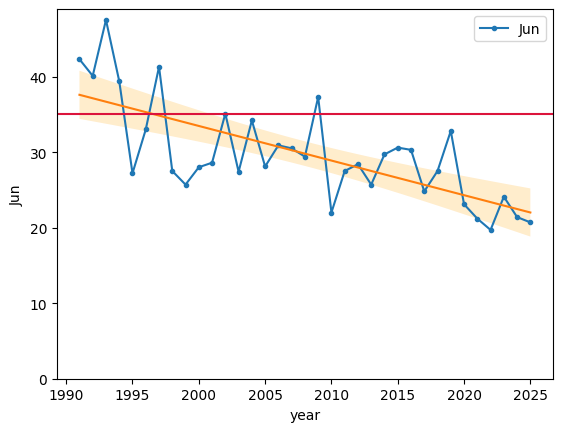

In [423]:
X = sm.add_constant(df_model["year_c"])
y = df_model[col]

# Fit logistic regression
model = sm.OLS(y, X)
result = model.fit()

print(result.summary())

# Prediction on observed data
pred = result.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

df_model["y_hat"] = pred_summary["mean"]
df_model["ci_lower"] = pred_summary["mean_ci_lower"]
df_model["ci_upper"] = pred_summary["mean_ci_upper"]


fig, ax = plt.subplots()

# Raw data
df_model.plot(x="year", y=col, ax=ax, marker=".")

# Fitted line
ax.plot(df_model["year"], df_model["y_hat"])

ax.axhline(thresh, color="crimson")

# Confidence band
ax.fill_between(
    df_model["year"],
    df_model["ci_lower"],
    df_model["ci_upper"],
    alpha=0.2,
    facecolor="orange",
)

ax.set_ylim(bottom=0)
ax.set_ylabel(col)

Optimization terminated successfully.
         Current function value: 0.309190
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:               Jun_trig   No. Observations:                   35
Model:                          Logit   Df Residuals:                       33
Method:                           MLE   Df Model:                            1
Date:                Tue, 24 Feb 2026   Pseudo R-squ.:                  0.3821
Time:                        22:18:38   Log-Likelihood:                -10.822
converged:                       True   LL-Null:                       -17.514
Covariance Type:            nonrobust   LLR p-value:                 0.0002537
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -2.6509      0.978     -2.711      0.007      -4.567      -0.734
year_c        -0.2317      0.

Text(0, 0.5, 'Estimated return period')

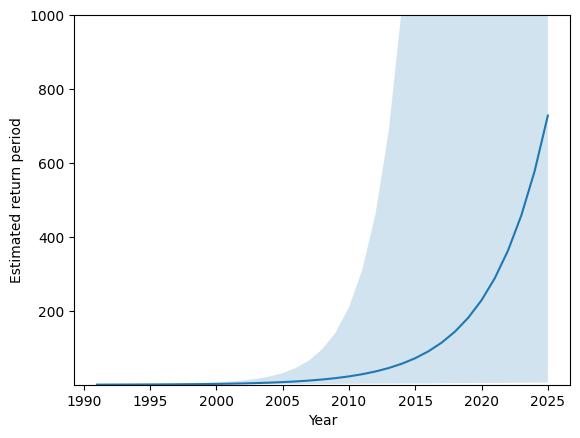

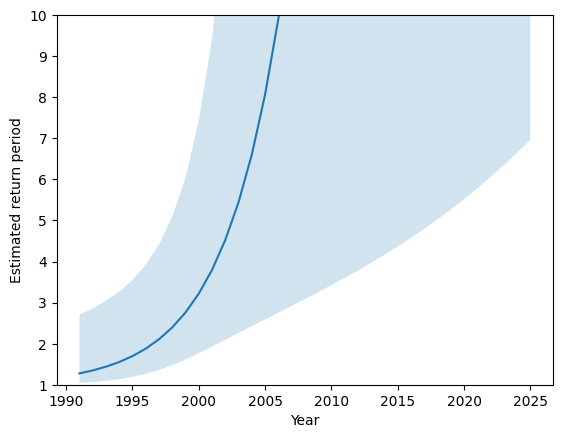

In [393]:
col = "Jun"
df_model[f"{col}_trig"] = (
    df_model[col] >= df_model[col].nlargest(nyears_trig_model).min()
)

# Design matrix
X = sm.add_constant(df_model["year_c"])
y = df_model[f"{col}_trig"]

# Fit logistic regression
model = sm.Logit(y, X)
result = model.fit()

print(result.summary())

print(np.exp(result.params["year_c"]))

# Get prediction (already on probability scale for Logit)
pred = result.get_prediction(X)
pred_summary = pred.summary_frame(alpha=0.05)

# Inspect columns if unsure:
# print(pred_summary.columns)

# These are probabilities directly
p_mean = pred_summary["predicted"]
p_lower = pred_summary["ci_lower"]
p_upper = pred_summary["ci_upper"]

# Convert to return period
df_model["rp_hat"] = 1 / p_mean

# Inversion flips bounds
df_model["rp_lower"] = 1 / p_upper
df_model["rp_upper"] = 1 / p_lower

df_model["p_hat"] = result.predict(X)
df_model["rp_hat"] = 1 / df_model["p_hat"]

fig, ax = plt.subplots()

ax.plot(df_model["year"], df_model["rp_hat"])

ax.fill_between(
    df_model["year"], df_model["rp_lower"], df_model["rp_upper"], alpha=0.2
)

ax.set_ylim((1, 1000))

ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")

fig, ax = plt.subplots()

ax.plot(df_model["year"], df_model["rp_hat"])

ax.fill_between(
    df_model["year"], df_model["rp_lower"], df_model["rp_upper"], alpha=0.2
)

ax.set_ylim((1, 10))

ax.set_xlabel("Year")
ax.set_ylabel("Estimated return period")

In [398]:
df_model

,year,Jan,Feb,Mar,Apr,May,Jun,Humanitarian Bad Years (rank),EM-DAT Bad Years,CHIRPS Precip JAS (mm),...,d27_trig,year_c,p_hat,rp_hat,Jun_trig,y_hat,ci_lower,ci_upper,rp_lower,rp_upper
0,1991,29.4,31.0,31.9,32.6,30.5,42.3,16.0,None,62.1,...,True,-17.0,0.783790,1.275852,True,37.590952,34.402479,40.779426,1.044658,2.703916
1,1992,30.0,41.7,38.5,46.7,39.3,40.1,16.0,None,53.4,...,True,-16.0,0.741964,1.347775,True,37.132661,34.081705,40.183617,1.065071,2.858692
2,1993,32.6,37.6,33.9,37.2,38.3,47.5,16.0,None,70.4,...,False,-15.0,0.695192,1.438451,True,36.674370,33.758499,39.590241,1.094076,3.043434
3,1994,32.3,32.8,35.3,42.0,43.8,39.4,16.0,None,80.7,...,False,-14.0,0.644011,1.552768,True,36.216078,33.432506,38.999651,1.134645,3.269317
4,1995,33.7,31.6,24.5,30.8,31.3,27.2,16.0,None,91.1,...,False,-13.0,0.589313,1.696892,False,35.757787,33.103310,38.412265,1.190210,3.553271
5,1996,37.6,39.3,34.1,43.2,31.6,33.0,16.0,None,60.7,...,True,-12.0,0.532313,1.878593,False,35.299496,32.770419,37.828572,1.264239,3.921316
6,1997,34.2,39.6,42.4,28.9,36.1,41.3,16.0,None,71.2,...,False,-11.0,0.474458,2.107670,True,34.841204,32.433258,37.249151,1.359413,4.413707
7,1998,32.8,26.8,33.0,25.8,30.6,27.5,16.0,None,85.0,...,False,-10.0,0.417280,2.396474,False,34.382913,32.091148,36.674678,1.476518,5.092477
8,1999,36.3,31.3,35.8,40.3,27.5,25.7,30.0,None,99.1,...,False,-9.0,0.362243,2.760578,False,33.924622,31.743299,36.105945,1.613560,6.051882
9,2000,36.1,32.9,32.5,27.7,35.4,28.0,16.0,None,76.7,...,False,-8.0,0.310596,3.219615,False,33.466331,31.388795,35.543866,1.765900,7.432547


In [414]:
df_wf_trigs

,current_year,thresh,trig
0,1996,43.34,False
1,1997,42.30,False
2,1998,42.10,False
3,1999,41.90,False
4,2000,41.70,False
5,2001,41.50,False
6,2002,41.30,False
7,2003,41.06,False
8,2004,40.82,False
9,2005,40.58,False


/var/folders/66/764yc5p92nvdc_nm3xmy5rn40000gn/T/ipykernel_52385/458198860.py:24: RuntimeWarning: divide by zero encountered in scalar divide
  rp_eff = (current_year - 1991 + 1) / total_trigs


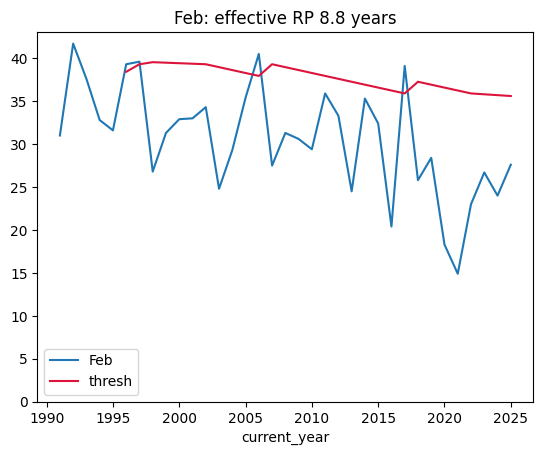

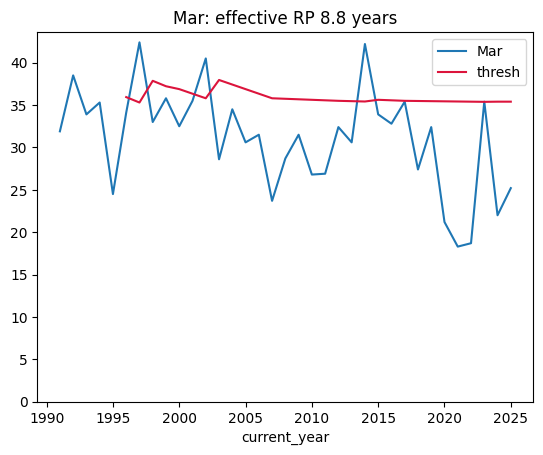

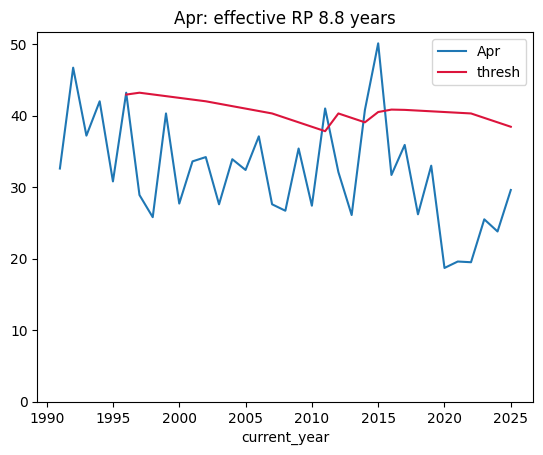

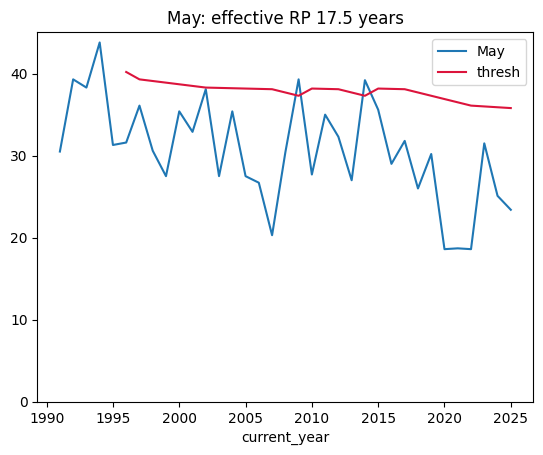

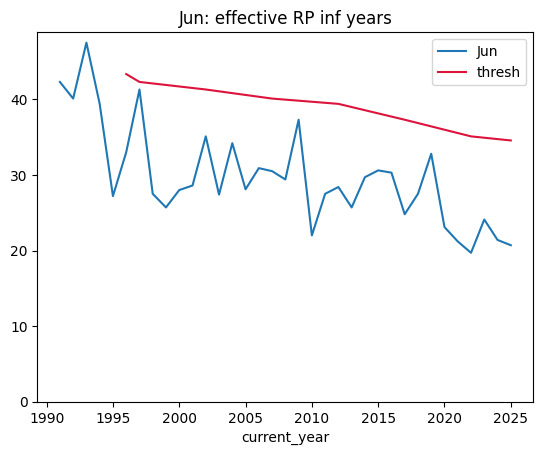

In [418]:
quantile = 0.2

for mo in range(2, 7):
    col = calendar.month_abbr[mo]

    dicts = []
    for current_year in range(1991 + 5, 2026):
        df_past = df_model[df_model["year"] < current_year]
        current_row = df_model.set_index("year").loc[current_year]
        thresh = df_past[col].quantile(1 - quantile)
        trig = current_row[col] >= thresh

        dicts.append(
            {
                "current_year": current_year,
                "thresh": thresh,
                "trig": trig,
            }
        )

    df_wf_trigs = pd.DataFrame(dicts)

    total_trigs = df_wf_trigs["trig"].sum()
    rp_eff = (current_year - 1991 + 1) / total_trigs

    fig, ax = plt.subplots()

    df_model.plot(y=col, x="year", ax=ax)
    df_wf_trigs.plot(x="current_year", y="thresh", ax=ax, color="crimson")

    ax.set_ylim(bottom=0)
    ax.set_title(f"{col}: effective RP {rp_eff:.1f} years")